In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [7]:
print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


In [8]:
iris =load_iris()
x = iris.data
feature_names = iris.feature_names
df = pd.DataFrame(x, columns=feature_names)
print("First 5 rows of dataset:")
print(df.head())


First 5 rows of dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


In [9]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)
df_scaled = pd.DataFrame(x_scaled, columns=feature_names)

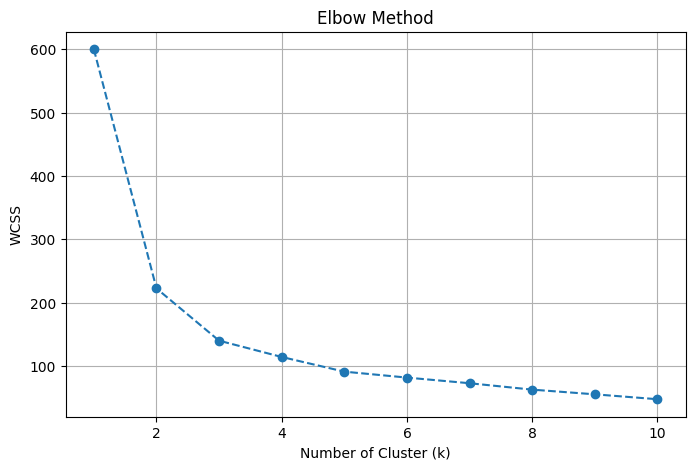

In [14]:
WCSS =[]
for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(x_scaled)
    WCSS.append(kmeans.inertia_)
plt.figure(figsize=(8,5))
plt.plot(range(1,11), WCSS, marker='o', linestyle='--')
plt.title("Elbow Method")
plt.xlabel("Number of Cluster (k)")
plt.ylabel("WCSS")
plt.grid(True)
plt.show()


In [15]:
kmeans =KMeans(n_clusters=3, random_state=42, n_init=10)
cluster =kmeans.fit_predict(x_scaled)
df['Cluster'] =cluster

In [16]:
score =silhouette_score(x_scaled, cluster)
print("Silhouette Score:", score)

Silhouette Score: 0.45994823920518635


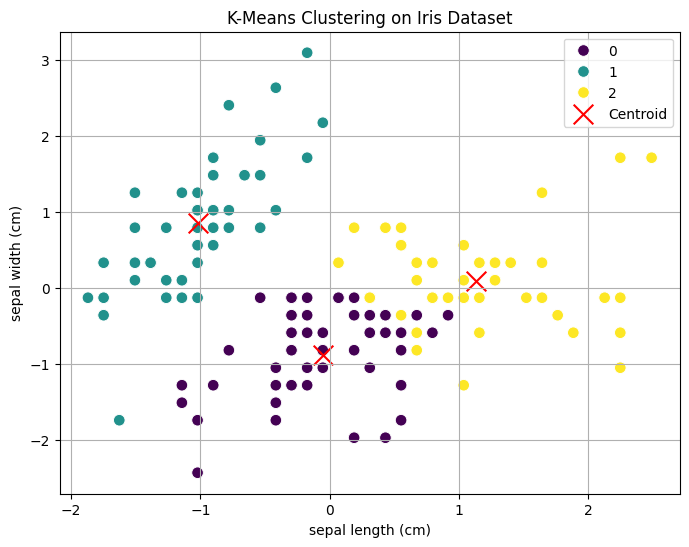

In [18]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=x_scaled[:,0], y=x_scaled[:,1], hue=cluster, palette='viridis', s=70)
centroid = kmeans.cluster_centers_
plt.scatter(centroid[:,0], centroid[:,1], s=200, c='red', marker='x', label='Centroid')
plt.title("K-Means Clustering on Iris Dataset")
plt.xlabel(feature_names[0])
plt.ylabel(feature_names[1])
plt.legend()
plt.grid(True)
plt.show()